# **Siti Naia Hesti Rachmawati | 24083010047**

# **Tugas 6 Machine Learning**

**Tugas Mata Kuliah Machine Learning Dari Tugas 1 Hingga Tugas Terakhir**

[tugas ML Naia (lengkap)](https://github.com/naiarch/mata-kuliah-machine-learning-semester-4)

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, ConfusionMatrixDisplay
from sklearn.tree import export_text

# **Load Data**

> Data yang digunakan adalah dataset Fisher's Iris, yang terdiri dari 150 sampel bunga Iris yang terbagi secara merata ke dalam 3 spesies (kelas) berbeda, yaitu: Setosa, Versicolor, dan Virginica, dengan masing-masing kelas berjumlah 50 sampel. Setiap sampel memiliki 4 fitur (features) berdimensi numerik yang merepresentasikan karakteristik fisik bunga, yaitu:

1. Sepal length (Panjang kelopak)

2. Sepal width (Lebar kelopak)

3. Petal length (Panjang mahkota)

4. Petal width (Lebar mahkota)

> Tujuan dari penugasan ini adalah mengimplementasikan algoritma Machine Learning dengan pendekatan Supervised Learning. Dalam pendekatan ini, model dilatih menggunakan sekumpulan data yang sudah memiliki label, dalam hal ini, spesies bunga. Model akan mempelajari pola hubungan antara keempat fitur fisik bunga (sebagai input atau prediktor) untuk dapat memprediksi secara akurat kelas spesies bunga (sebagai output atau target) pada data baru yang belum pernah dilihat sebelumnya.

> Untuk menyelesaikan masalah klasifikasi multiclass ini, algoritma yang diimplementasikan adalah Decision Tree Classifier. Algoritma ini dipilih karena beberapa alasan:

1. Decision Tree menghasilkan serangkaian aturan logika kondisional (if-else) yang sangat mudah diinterpretasikan. Hal ini memudahkan proses pelacakan bagaimana model mengambil suatu keputusan klasifikasi berdasarkan ukuran sentimeter pada kelopak atau mahkota bunga.

2. Algoritma ini bersifat non-parametrik, sehingga tidak mengharuskan data terdistribusi secara normal atau memiliki hubungan linier antar fitur.

3. Decision Tree terbukti sangat tangguh dan mampu memberikan tingkat akurasi yang tinggi pada dataset dengan jumlah sampel dan dimensi yang relatif kecil seperti Fisher's Iris.

In [31]:
iris = load_iris()

df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['target'] = iris.target
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


In [33]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [34]:
target_names = {0: 'Setosa', 1: 'Versicolor', 2: 'Virginica'}
print(df['target'].map(target_names).value_counts())

target
Setosa        50
Versicolor    50
Virginica     50
Name: count, dtype: int64


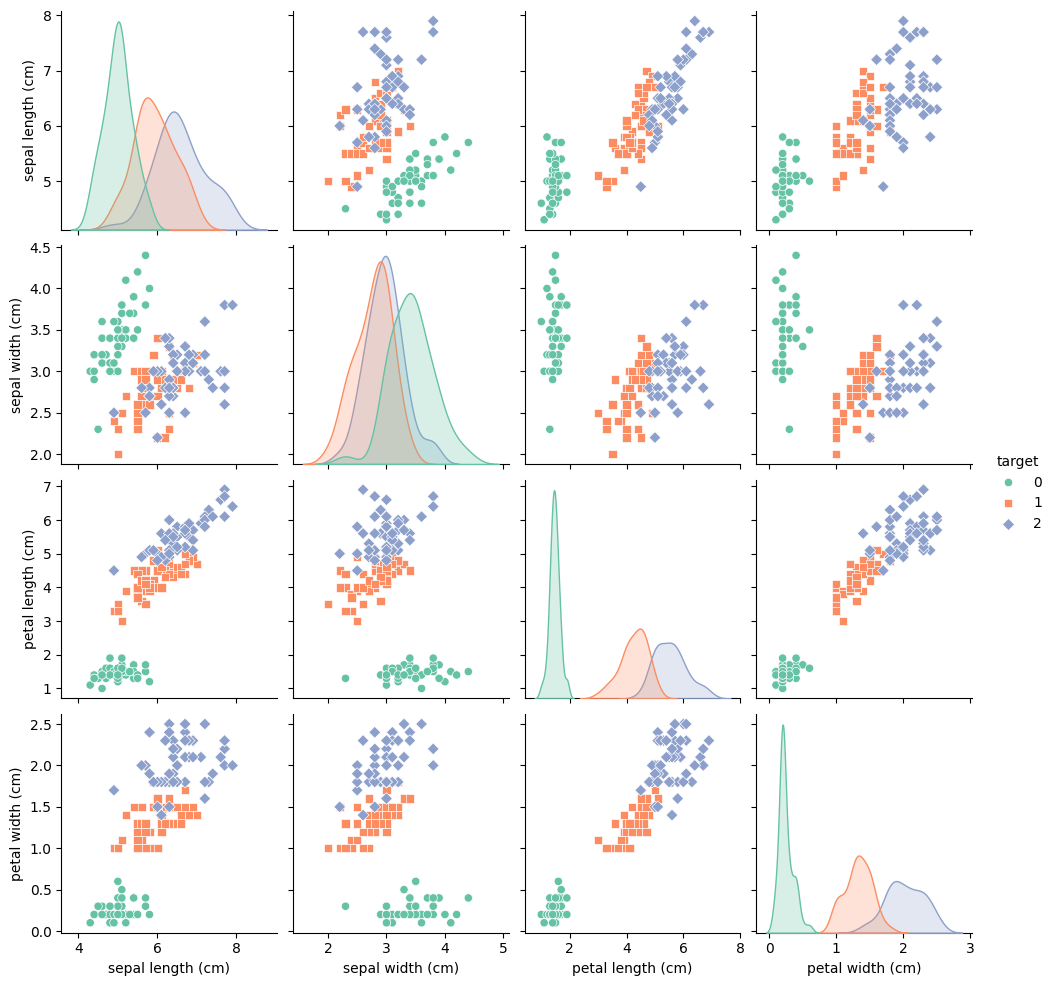

In [35]:
# @title visualisasi sebaran data
sns.pairplot(df, hue='target', palette='Set2', markers=["o", "s", "D"])
plt.show()

> Untuk memahami karakteristik dan pola distribusi dataset Fisher's Iris sebelum dilakukannya pemodelan, dilakukan analisis visual menggunakan Pairplot. Grafik ini menampilkan distribusi univariat (pada garis diagonal) dan hubungan bivariat (pada grafik scatter di luar diagonal) untuk keempat fitur yang ada, dengan pemisahan warna berdasarkan kelas target: Setosa (Target 0 - Hijau), Versicolor (Target 1 - Oranye), dan Virginica (Target 2 - Biru).

> Separabilitas Kelas Setosa (Target 0)
>> Kelas Setosa (titik hijau) menunjukkan pemisahan yang sangat jelas (linearly separable) dari kedua kelas lainnya di hampir setiap kombinasi fitur. Hal ini paling terlihat pada grafik yang melibatkan fitur ukuran mahkota (petal length dan petal width), di mana kelompok Setosa mengelompok di area nilai yang sangat rendah dan memiliki jarak pemisah (margin) yang jauh dari kelompok lain. Karakteristik inilah yang membuat algoritma machine learning dapat mengenali kelas Setosa dengan akurasi 100% tanpa kesulitan.

> Overlapping antara Versicolor dan Virginica
>> Berbeda dengan Setosa, kelas Versicolor (Target 1 - Oranye) dan Virginica (Target 2 - Biru) memiliki sebaran data yang cenderung berdekatan dan tumpang tindih pada area tertentu. Meskipun secara umum ukuran Virginica sedikit lebih besar, batas pemisah di antara keduanya, terutama pada fitur ukuran kelopak (sepal length dan sepal width), tidak terlihat tegas. Tumpang tindih inilah yang menjadi tantangan utama bagi algoritma dan merupakan penyebab utama dari potensi kesalahan prediksi (misclassification) pada model.

> Kekuatan Diskriminatif Fitur (Feature Importance)
>> Dengan mengamati plot kepadatan distribusi (density plots/KDE) pada garis diagonal, terlihat jelas bahwa fitur Petal Length dan Petal Width memiliki kekuatan diskriminatif (kemampuan membedakan kelas) yang jauh lebih tinggi dibandingkan fitur Sepal. Pada kurva petal, ketiga puncak distribusi spesies terlihat membentuk bukit yang cukup terpisah. Sebaliknya, pada kurva sepal width, distribusi ketiga kelas saling menumpuk menjadi satu gundukan besar.

> Temuan dari visualisasi ini berbanding lurus dengan aturan yang dibentuk oleh model Decision Tree pada tahap pelatihan. Algoritma secara otomatis memilih fitur Petal Length sebagai akar (keputusan pertama) untuk memisahkan data, karena fitur inilah yang secara visual memiliki celah kosong (pemisah) paling lebar antara kelompok Setosa dengan dua kelompok lainnya di kisaran angka 2.0 hingga 2.5 cm.

# **Modelling**

In [36]:
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=47)

print("Jumlah data untuk Training:", X_train.shape[0], "baris")
print("Jumlah data untuk Testing:", X_test.shape[0], "baris")

Jumlah data untuk Training: 120 baris
Jumlah data untuk Testing: 30 baris


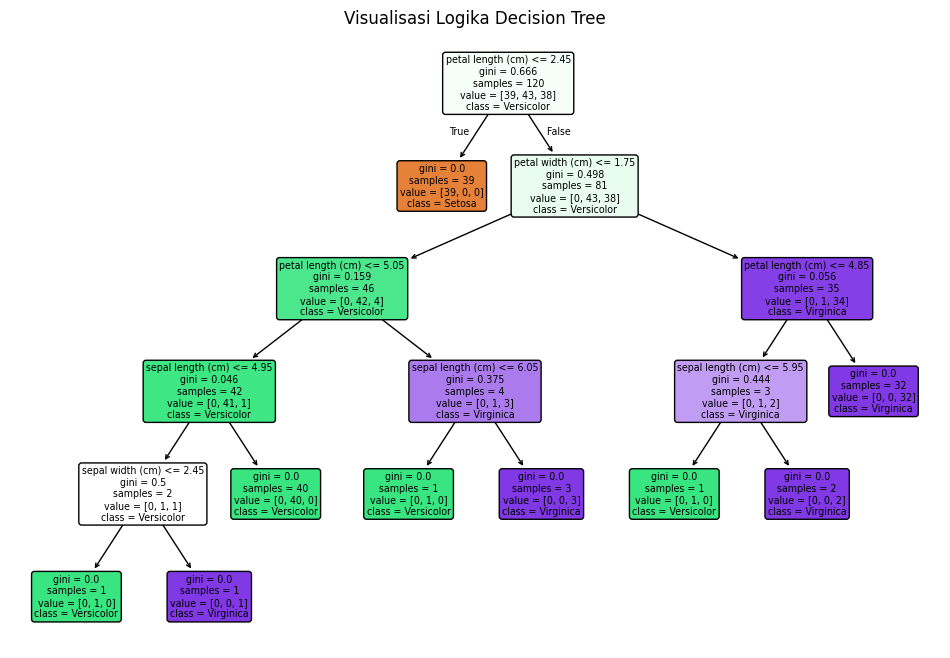

In [37]:
model_dt = DecisionTreeClassifier(random_state=42)
model_dt.fit(X_train, y_train)

y_pred = model_dt.predict(X_test)

plt.figure(figsize=(12,8))
plot_tree(model_dt, feature_names=X.columns, class_names=['Setosa', 'Versicolor', 'Virginica'], filled=True, rounded=True)
plt.title("Visualisasi Logika Decision Tree")
plt.show()

In [38]:
# menghitung metrik evaluasi
akurasi = accuracy_score(y_test, y_pred)

# menghitung presisi dan recall
presisi = precision_score(y_test, y_pred, average='macro')
recall = recall_score(y_test, y_pred, average='macro')

print("Hasil Evaluasi Performa Model")
print(f"Akurasi  : {akurasi * 100:.2f}%")
print(f"Presisi  : {presisi * 100:.2f}%")
print(f"Recall   : {recall * 100:.2f}%")

Hasil Evaluasi Performa Model
Akurasi  : 96.67%
Presisi  : 95.83%
Recall   : 97.22%


In [39]:
aturan_tree = export_text(model_dt, feature_names=list(X.columns))

print("Aturan Logika Decision Tree")
print(aturan_tree)

Aturan Logika Decision Tree
|--- petal length (cm) <= 2.45
|   |--- class: 0
|--- petal length (cm) >  2.45
|   |--- petal width (cm) <= 1.75
|   |   |--- petal length (cm) <= 5.05
|   |   |   |--- sepal length (cm) <= 4.95
|   |   |   |   |--- sepal width (cm) <= 2.45
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- sepal width (cm) >  2.45
|   |   |   |   |   |--- class: 2
|   |   |   |--- sepal length (cm) >  4.95
|   |   |   |   |--- class: 1
|   |   |--- petal length (cm) >  5.05
|   |   |   |--- sepal length (cm) <= 6.05
|   |   |   |   |--- class: 1
|   |   |   |--- sepal length (cm) >  6.05
|   |   |   |   |--- class: 2
|   |--- petal width (cm) >  1.75
|   |   |--- petal length (cm) <= 4.85
|   |   |   |--- sepal length (cm) <= 5.95
|   |   |   |   |--- class: 1
|   |   |   |--- sepal length (cm) >  5.95
|   |   |   |   |--- class: 2
|   |   |--- petal length (cm) >  4.85
|   |   |   |--- class: 2



> Berdasarkan hasil pelatihan dengan proporsi data latih sebanyak 120 baris, algoritma berhasil membentuk pohon keputusan (Decision Tree) untuk mengklasifikasikan spesies bunga Iris. Struktur visual pohon dan ekstraksi aturan teksnya menunjukkan bagaimana mesin melakukan pemisahan secara hierarkis

1. Pemisahan Utama (Root Node)
> Keputusan paling pertama dan paling signifikan yang diambil oleh model adalah mengecek fitur Petal Length dengan ambang batas pemisah 2.45 cm. Dari 120 sampel data latih, 39 sampel yang memiliki petal length $\le$ 2.45 cm langsung dipisahkan secara sempurna ke daun sebelah kiri dan diklasifikasikan sebagai Setosa. Daun ini memiliki nilai Gini = 0.0, yang berarti data di dalamnya 100% murni tanpa tercampur spesies lain. Hal ini secara langsung memvalidasi temuan pada tahap Exploratory Data Analysis (EDA) bahwa Setosa berpisah secara tegas dari kelas lainnya.

2. Penanganan Data Overlapping (Internal Nodes)
> Sebanyak 81 sampel sisa (yang bukan Setosa) diteruskan ke cabang kanan. Untuk memisahkan Versicolor dan Virginica, model memilih fitur Petal Width dengan ambang batas 1.75 cm sebagai pemisah terbaik kedua.

3. Kompleksitas Pohon
> Karena sebaran data Versicolor dan Virginica memiliki area irisan yang cukup padat, model harus membuat percabangan yang jauh lebih dalam ke bawah. Model harus melakukan pengecekan berlapis terhadap ukuran sepal length dan sepal width secara spesifik untuk membedah titik-titik data yang berdekatan tersebut hingga akhirnya mencapai simpul daun akhir (leaf nodes) dengan kemurnian maksimal (Gini = 0.0).

> Setelah model dilatih, pengujian dilakukan menggunakan 30 baris data testing yang sebelumnya tidak pernah dilihat oleh mesin.

1. Akurasi (96.67%)
> Tingkat akurasi ini menginterpretasikan bahwa dari 30 soal ujian klasifikasi, model berhasil menebak 29 data dengan benar dan hanya meleset 1 kali. Angka ini membuktikan bahwa aturan if-else yang dibentuk pada tahap training memiliki kemampuan generalisasi yang sangat kuat ketika dihadapkan pada data baru.

> Presisi (95.83%) dan Recall (97.22%)
> Nilai presisi dan recall yang tinggi namun tidak menyentuh angka 100% merupakan indikator model yang terhindar dari overfitting. Selisih kecil dari angka sempurna ini mencerminkan adanya probabilitas kesalahan kecil (misclassification) ketika mesin mencoba menebak bunga Versicolor yang ukurannya menyerupai Virginica (atau sebaliknya). Kesalahan minor ini sangat dapat ditoleransi karena batas keputusan (decision boundary) alami antara kedua kelas tersebut memang sangat tipis.

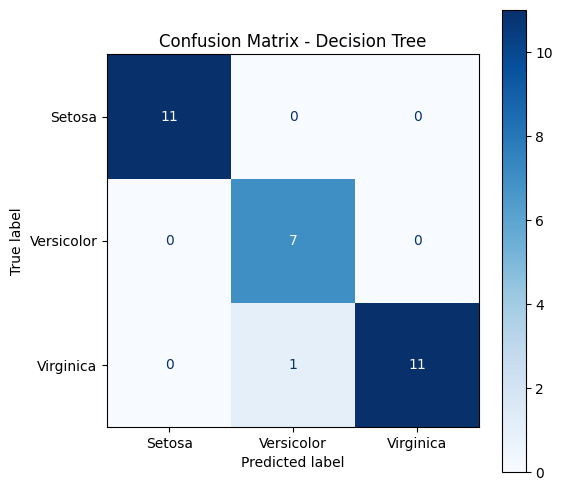

In [40]:
# confussion matrix
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Setosa', 'Versicolor', 'Virginica'])

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, cmap=plt.cm.Blues, values_format='d')
plt.title("Confusion Matrix - Decision Tree")
plt.show()

> Confusion Matrix adalah instrumen evaluasi visual yang memetakan performa algoritma klasifikasi dengan membandingkan kelas asli data (True Label pada sumbu Y) dengan kelas hasil tebakan mesin (Predicted Label pada sumbu X).

1. Prediksi Tepat (Garis Diagonal Utama)
> Area diagonal yang ditandai dengan warna biru gelap menunjukkan jumlah tebakan yang akurat. Model secara sempurna berhasil mengenali 11 sampel Setosa, 7 sampel Versicolor, dan 11 sampel Virginica sesuai dengan identitas aslinya. Secara kumulatif, model berhasil menebak 29 dari 30 data dengan benar.

2. Kesalahan Prediksi (Misclassification)
> Terdapat satu angka di luar garis diagonal, tepatnya pada persimpangan baris Virginica dan kolom Versicolor. Hal ini mengindikasikan adanya 1 sampel bunga yang wujud aslinya adalah Virginica, tetapi secara keliru diprediksi oleh model sebagai Versicolor (berupa kasus False Negative untuk kelas Virginica dan False Positive untuk kelas Versicolor).

> Kesalahan tunggal ini membuktikan perhitungan persentase akurasi model, di mana ketepatan 29 dari 30 tebakan setara dengan nilai akurasi sebesar 96.67%. Temuan ini memvalidasi hasil Exploratory Data Analysis (EDA), yang secara visual menunjukkan bahwa ukuran petal dan sepal dari kedua spesies tersebut saling beririsan (overlapping) pada ambang batas tertentu. Kemiripan fitur fisik inilah yang menyebabkan model Decision Tree mengambil rute cabang if-else yang salah pada satu sampel data yang berada tepat di area abu-abu tersebut. Sebaliknya, prediksi untuk Setosa mendapatkan skor mutlak karena jarak antar kelasnya memang terpisah secara ekstrem.